In [91]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
df=pd.read_csv("C:/Users/vidhy/OneDrive/Pictures/Documents/poly.csv")
df

,sno,Temperature,Pressure
0,1,0,0.0002
1,2,20,0.0012
2,3,40,0.0060
3,4,60,0.0300
4,5,80,0.0900
5,6,100,0.2700


In [92]:
df.shape

(6, 3)

In [93]:
df.columns

Index(['sno', 'Temperature', 'Pressure'], dtype='object')

In [94]:
df.dtypes

sno              int64
Temperature      int64
Pressure       float64
dtype: object

In [95]:
df.head()

,sno,Temperature,Pressure
0,1,0,0.0002
1,2,20,0.0012
2,3,40,0.0060
3,4,60,0.0300
4,5,80,0.0900


In [96]:
df.tail()

,sno,Temperature,Pressure
1,2,20,0.0012
2,3,40,0.0060
3,4,60,0.0300
4,5,80,0.0900
5,6,100,0.2700


In [97]:
df.isna().sum()

sno            0
Temperature    0
Pressure       0
dtype: int64

In [98]:
df.drop(['sno'],axis=1,inplace=True)


In [99]:
x=df.iloc[:,:-1]
y=df.iloc[:,-1]

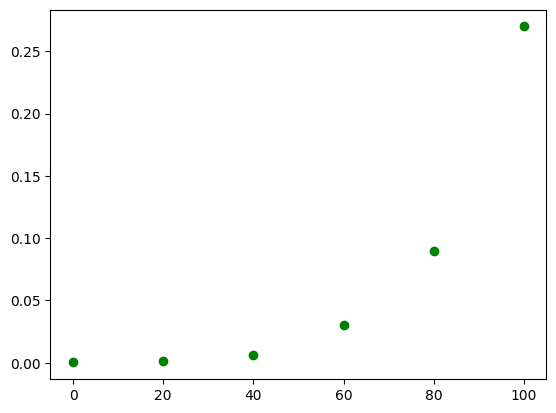

In [100]:
plt.scatter(x,y,color='g')

In [101]:
from sklearn.linear_model import LinearRegression
model=LinearRegression()
model.fit(x,y)
y_pred=model.predict(x)
y_pred

array([-0.05086667, -0.00402667,  0.04281333,  0.08965333,  0.13649333,
        0.18333333])

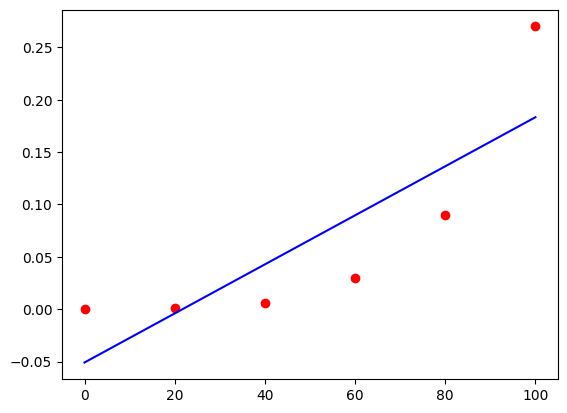

In [102]:
plt.scatter(x,y,color='r')
plt.plot(x,y_pred,color='b')

In [103]:
print(model.coef_)

[0.002342]


In [104]:
print(model.intercept_)

-0.05086666666666667


In [105]:
df1=pd.DataFrame({'actual value':y,'predicted value':y_pred,'difference':y-y_pred})
df1

,actual value,predicted value,difference
0,0.0002,-0.050867,0.051067
1,0.0012,-0.004027,0.005227
2,0.0060,0.042813,-0.036813
3,0.0300,0.089653,-0.059653
4,0.0900,0.136493,-0.046493
5,0.2700,0.183333,0.086667


In [106]:
from sklearn.metrics import mean_absolute_percentage_error,r2_score
mape=mean_absolute_percentage_error(y,y_pred)
mape

44.775078189300416

In [107]:
score=r2_score(y,y_pred)
score

0.690349972603981

In [108]:
# polynomial
from sklearn.preprocessing import PolynomialFeatures
poly=PolynomialFeatures(degree=3)
x_poly=poly.fit_transform(x)
x_poly

array([[1.00e+00, 0.00e+00, 0.00e+00, 0.00e+00],
       [1.00e+00, 2.00e+01, 4.00e+02, 8.00e+03],
       [1.00e+00, 4.00e+01, 1.60e+03, 6.40e+04],
       [1.00e+00, 6.00e+01, 3.60e+03, 2.16e+05],
       [1.00e+00, 8.00e+01, 6.40e+03, 5.12e+05],
       [1.00e+00, 1.00e+02, 1.00e+04, 1.00e+06]])

In [109]:
model1=LinearRegression()
model1.fit(x_poly,y)
y_poly=model1.predict(x_poly)
y_poly

array([-0.00198889,  0.00724444,  0.00371111,  0.02248889,  0.09865556,
        0.26728889])

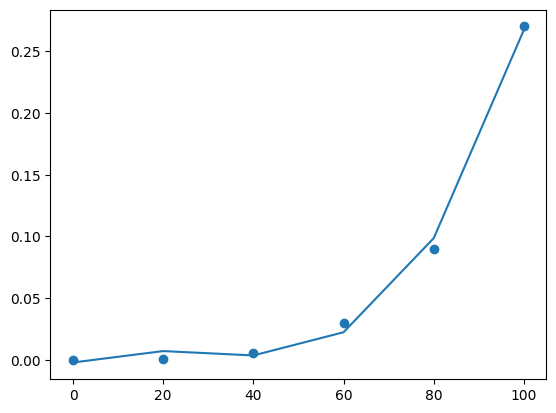

In [110]:
plt.scatter(x,y)
plt.plot(x,y_poly)

In [111]:
mape1=mean_absolute_percentage_error(y,y_poly)
mape1

2.7865912208924066

In [112]:
score1=r2_score(y,y_poly)
score1

0.9966691251761722